In [1]:
# Core Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# Data Processing
import numpy as np
import os
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt

# Machine Learning Tools
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Utilities (optional if dataset is downloaded locally)
import requests
from io import BytesIO
import zipfile
import shutil


C:\Users\wwwra\.conda\envs\RagulDl\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
train_dir =r"C:\Users\wwwra\Downloads\archive (6)\train"

In [3]:
# 3. Data preprocessing
# --------------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% validation
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 559 images belonging to 2 classes.
Found 138 images belonging to 2 classes.


In [4]:
# 4. Model (Transfer Learning with VGG16)
# --------------------------------
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(150,150,3))
base_model.trainable = False  # freeze pre-trained layers

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")   # binary classification
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,763,521 (60.13 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
# 5. Training
# --------------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9875 - loss: 0.0974 - val_accuracy: 0.8623 - val_loss: 0.2811
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9875 - loss: 0.0991 - val_accuracy: 0.8696 - val_loss: 0.2798
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9875 - loss: 0.0914 - val_accuracy: 0.8841 - val_loss: 0.2827
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9857 - loss: 0.0854 - val_accuracy: 0.8696 - val_loss: 0.2887
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9893 - loss: 0.0826 - val_accuracy: 0.8696 - val_loss: 0.2874
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9928 - loss: 0.0747 - val_accuracy: 0.8696 - val_loss: 0.2857
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 1.0000 - loss: 0.0658 - val_accuracy: 0.8696 - val_loss: 0.2856
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9946 - loss: 0.0614 - val_accuracy: 0.8696 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 809ms/step - accuracy: 0.8623 - loss: 0.3049
Validation Accuracy: 0.8623
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 860ms/step
              precision    recall  f1-score   support

         Cat       0.59      0.65      0.62        69
         Dog       0.61      0.55      0.58        69

    accuracy                           0.60       138
   macro avg       0.60      0.60      0.60       138
weighted avg       0.60      0.60      0.60       138



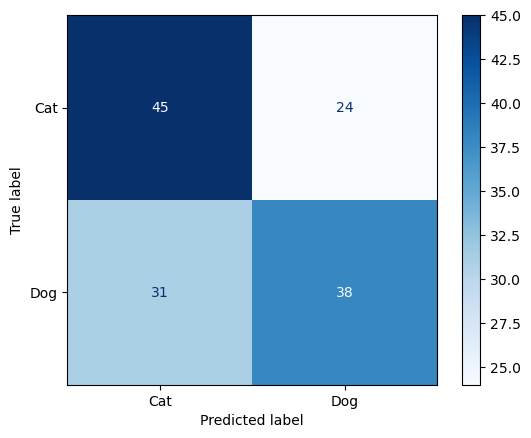

In [9]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc:.4f}")
y_true = val_generator.classes
y_pred = (model.predict(val_generator) > 0.5).astype("int32")
print(classification_report(y_true, y_pred, target_names=["Cat","Dog"]))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Cat","Dog"]).plot(cmap="Blues")
plt.show()


In [13]:
# 7. Test on new image
# --------------------------------
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(150,150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)[0][0]
    if prediction > 0.5:
        print(f"{os.path.basename(img_path)} → Dog 🐶 ({prediction:.2f})")
    else:
        print(f"{os.path.basename(img_path)} → Cat 🐱 ({prediction:.2f})")

# Example test
predict_image(r"C:\Users\wwwra\OneDrive\Pictures\R.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
R.jpeg → Cat 🐱 (0.05)


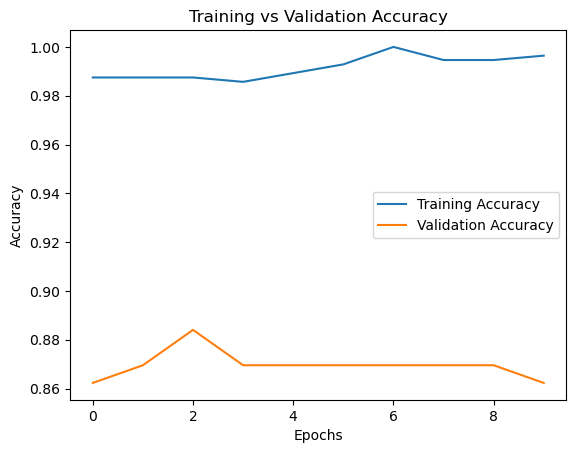

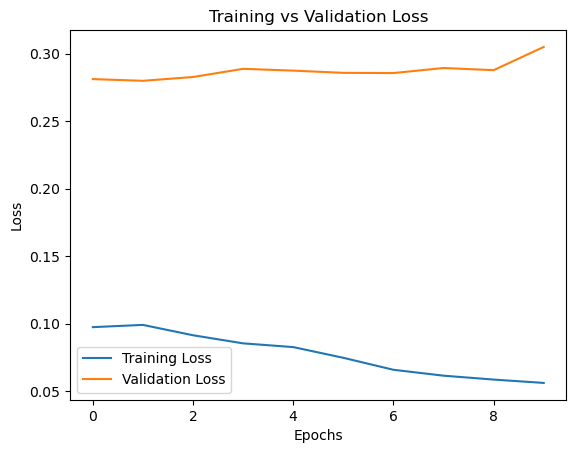

In [14]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()
